# The workbench

The live devising path, one call at a time, with everything it sends and everything it gets back on the page. Nothing here is a copy: the prompts are read out of `agents/` and `shared/`, and the calls are the ones `panel/devising.py` and `panel/continuing.py` make.

Where the product loops on its own — a repair, a check, the gate — there is a cell, so what it does silently in a container is visible here in order.

One afternoon is n=1. What to try is decided here; whether it worked is answered by `python -m research.run`.

In [1]:
import os
import secrets
import sys
import time
from pathlib import Path

ROOT = Path.cwd().resolve()
while not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

import research.bench as bench  # noqa: E402
from agents.experience_deviser import ExperienceDeviser, experience_in, the_prompt  # noqa: E402
from orchestrator.router import FoundryConfig, FoundryRouter  # noqa: E402
from orchestrator.safety import (  # noqa: E402
    AzureContentSafetyGate,
    ContentSafetyConfig,
    screen_experience,
)
from shared.agents import AgentContext  # noqa: E402
from shared.ids import LearnerId  # noqa: E402
from shared.seal import Sealer, SealPurpose  # noqa: E402

bench.environment()

# Built exactly as `panel/devising.py` builds it, so the gate and the router here are the
# ones production uses. The safety key is per-process: the seal this gate mints travels
# nowhere, on this path or on that one.
ENVIRONMENT = dict(os.environ)
KEY = ENVIRONMENT.get("LANTERNINA_SAFETY_KEY", "").encode() or secrets.token_bytes(32)
GATE = AzureContentSafetyGate(
    ContentSafetyConfig.from_env(ENVIRONMENT),
    Sealer(SealPurpose.CONTENT_SAFETY, KEY, "orchestrator.safety"),
)
ROUTER = FoundryRouter(FoundryConfig.from_env(ENVIRONMENT), gate=GATE)
CTX = AgentContext(router=ROUTER, learner_id=LearnerId(""), learner_hints={}, now=time.time())
DEVISER = ExperienceDeviser()

print("prompt fingerprint:", bench.reload_prompts())

prompt fingerprint: bdbfb5b564f4


## The calls, in order

Five, and every one of them is the call the container makes. `panel/devising.py` runs 1 to 4 inside one request and returns; `panel/continuing.py` runs 6 when a page comes back off the glass.

```mermaid
flowchart TD
  A["1 · which method<br/>experience_deviser.choosing<br/>a catalogue of 60 names, no records"]
  B["2 · the afternoon<br/>task · format · shape-of-a-moment · acts<br/>marks-on-a-page · ten-dimensions · rules<br/>limits · asking · manner · worth-doing<br/>method · household"]
  C{"does the format<br/>read the answer?"}
  U["3a · repair_unreadable<br/>repair + the refusal + the answer"]
  K{"do the seven<br/>checks pass?"}
  R["3b · repair<br/>repair + the complaints + the document"]
  G["4 · the gate<br/>Azure Content Safety"]
  W["the walk, one moment at a time"]
  P["5 · the page<br/>page_maker.*<br/>gpt-image-2"]
  S["the stand-in<br/>research/calls.adolescent<br/>ours, not the product's"]
  N["6 · the continuation<br/>experience_continuer.*"]
  A -->|"a form and a move"| B
  B --> C
  C -->|no| U
  U --> K
  C -->|yes| K
  K -->|no, once| R
  R --> G
  K -->|yes| G
  G --> W
  W -->|"at every hand_over"| P
  W -->|"at every collect"| S
  S -->|"marks or blank"| W
  S -->|"the outcome says ask"| N
  N --> W
```

| # | call | what it is sent | what comes back | measured |
| --- | --- | --- | --- | --- |
| 1 | which method | `choosing`, and a sample of 60 method names | two ids and a reason | a few seconds |
| 2 | the afternoon | the whole standing instruction plus the household's material, about 34 000 characters | one JSON document: title, overview, themes, script, minutes, drawn, moments | 76–184 s, median about 140 |
| 3 | a repair | `repair`, what was refused, and the document as it was | the same JSON again | once, and only if something refused |
| 4 | the gate | the document's own words | a pass, or `SafetyBlocked` | seconds |
| 5 | the page | `page_maker.*`, built from the page's own words | one PNG | 25–35 s a page |
| 6 | the continuation | `experience_continuer.*`, the afternoon so far and what came back on the sheet | the rest of the moments | 15–25 s |

The stand-in is the one call in this notebook the house never makes: it is `research/calls.adolescent.md`, and it exists so an afternoon can be walked with nobody in the room.

Credentials are not in `env.ps1`: the router builds a `DefaultAzureCredential`, which finds the `az` session in the `AZURE_CONFIG_DIR` named there. If a call fails on authentication, run `az account get-access-token` in a terminal with that variable set — `az account show` reads the cache and succeeds even on an expired token.

## 1. The prompts, as they are

Every block, with the format's own numbers filled in. The placeholders left as `$name` are the ones that carry a household's material, and the cell after next is where they are filled.

In [2]:
P = bench.everything()

for key, text in P.items():
    print(f"{key:26} {len(text):6}")
print(f"{'':26} {sum(len(one) for one in P.values()):6}  in all")

task                         2077
format                       4935
shape-of-a-moment            2765
acts                         1099
marks-on-a-page              3466
ten-dimensions               1135
rules-head                     88
limits                        482
rules-tail                    713
asking                        376
manner-head                   391
how-the-text-reads            860
what-to-refuse                421
only-what-you-can-answer     1399
worth-doing                  5117
manner-tail                   114
method                        810
household                    1391
pitch                         516
stand-in                     1535
                            29690  in all


In [3]:
print(P["task"])

You are making one afternoon for one adolescent to spend at home, mostly on their own, in a house with a printer, a scanner and a small screen or two. Not a lesson, not a test, and not an exercise with a story painted over it. One thing worth doing, that happens once, and is over when it is over.

A parent glances at your overview before this happens, and may add something of their own. That is not a tribunal and you are not defending anything: they are seeing roughly what is coming, for somebody they know and you do not. Write the overview so that one glance says what this afternoon actually is. Nothing here is set in stone either — an afternoon can turn out differently once it has started, and that is ordinary rather than a failure.

An afternoon is a good one when four things are true of it.

Somebody can start it alone. The first screen puts a situation in front of them, they can see what to pick up, and no adult has to explain anything first.

Something is genuinely not known, and

## 2. The household

Everything that decides one afternoon, as one dictionary. `research/run.py` sends the same one to `devise_experience`.

In [4]:
from research.households import Household, Memory, arguments

HOUSE = Household(
    name="bench",
    interests=("i treni", "le mappe vecchie"),
    avoid=("i ragni",),
    load="middle",
    ink="middle",
    span="middle",
    sheets=2,
    note="",
)
MEMORY = Memory()  # no history: the first afternoon of this house
ARGS = arguments(HOUSE, MEMORY)

for name, value in ARGS.items():
    shown = value if isinstance(value, str) else repr(value)
    print(f"{name:12} {shown[:110] or '—'}")

capabilities frozenset({<HouseCapability.SHOW_800X480_1BIT: 'show_800x480_1bit'>, <HouseCapability.SCAN_A4: 'scan_a4'>, <Ho
language     Italian
interests    ('i treni', 'le mappe vecchie')
avoid        ('i ragni',)
pitch        two things that have to be put side by side before either makes sense, and one turn where what looked true sto
sheets       2
note         —
already      ()
recent       ()
happened     —
counts       {"afternoonsRun": 0, "ranToTheEnd": 0, "endedEarly": 0, "stopped": 0, "sheetsWrittenOn": 0, "sheetsBlank": 0}
direction    Ask for about what the last ones asked for. Nothing here says to move either way.
ground       —


## 3. Call one: which method

A cheap call before the expensive one. It carries a sample of sixty names out of `methods/` and no records, so the corpus stays outside the prompt. The sample is there because the whole catalogue made the model pick the same pair twice out of twice: the same judgement on the same list gives the same answer, which was worse than drawing.

In [5]:
from shared.methods import CATALOGUE, by_id, draw, index, load, runnable

RUNNABLE = runnable(load(), capabilities=ARGS["capabilities"])
CATALOGUE_SENT = index(RUNNABLE, sample=CATALOGUE)
print(f"{len(RUNNABLE)} methods this house can run · {len(CATALOGUE_SENT)} characters of names\n")
print(CATALOGUE_SENT[:1200])

145 methods this house can run · 5070 characters of names

cut-where-the-counting-stops: cut the printed part where the counting stops (a move)
a-rule-then-seven-cases: write a rule, then meet seven cases it must judge
the-chain-that-comes-back-to-your-own-number: a chain of steps ending on a number only you know
two-strips-and-the-ladder-that-breaks-them: cut a cipher wheel, then break it in twenty-one rows
two-rules-run-five-times: run a two-rule model five times and compare the runs
which-one-nearly-went-the-other-way: ask which one nearly went the other way (a move)
two-sheets-held-against-the-light: lay one printed sheet on another and read the third thing
sixteen-digits-and-one-rule-more: cross a grid of digits, then add a rule and cross again
six-squares-and-no-task: hand over six squares, a joining rule and no task
describe-it-without-its-name: make an object talk without saying what it is
an-instrument-built-and-read-more-than-once: build the instrument, then take the reading 

In [6]:
began = time.time()
WANTS_FORM, WANTS_MOVE, WHY = await DEVISER.choose(
    CTX,
    catalogue=CATALOGUE_SENT,
    interests=ARGS["interests"],
    avoid=ARGS["avoid"],
    already=ARGS["already"],
    pitch=ARGS["pitch"],
)
ASKED_FOR = by_id(RUNNABLE, [WANTS_FORM, WANTS_MOVE])
FORM = next((one for one in ASKED_FOR if not one.is_a_move), None)
MOVE = next((one for one in ASKED_FOR if one.is_a_move), None)
if FORM is None or MOVE is None:
    # What `panel/devising.py` does: a step that exists to improve an afternoon may never
    # be the step that costs one.
    FORM, MOVE = draw(RUNNABLE)
    print("the choice did not resolve; drew instead")
print(f"{time.time() - began:.1f} s · {FORM.method_id} + {MOVE.method_id}\n{WHY}")

17.3 s · two-sheets-held-against-the-light + answer-in-the-part-nobody-searches
An old map and a rail map reveal a hidden route together, before a marginal clue overturns it.


## 4. The whole prompt, before paying for it

In [7]:
PROMPT = the_prompt(**ARGS, form=FORM, move=MOVE)
print(f"{len(PROMPT)} characters\n")
print(PROMPT)

34081 characters

You are making one afternoon for one adolescent to spend at home, mostly on their own, in a house with a printer, a scanner and a small screen or two. Not a lesson, not a test, and not an exercise with a story painted over it. One thing worth doing, that happens once, and is over when it is over.

A parent glances at your overview before this happens, and may add something of their own. That is not a tribunal and you are not defending anything: they are seeing roughly what is coming, for somebody they know and you do not. Write the overview so that one glance says what this afternoon actually is. Nothing here is set in stone either — an afternoon can turn out differently once it has started, and that is ordinary rather than a failure.

An afternoon is a good one when four things are true of it.

Somebody can start it alone. The first screen puts a situation in front of them, they can see what to pick up, and no adult has to explain anything first.

Something is genuin

## 5. Call two: the afternoon

One answer, whole. Measured at 76–184 s, median about 140.

In [8]:
began = time.time()
ANSWER = await DEVISER.ask(CTX, **ARGS, form=FORM, move=MOVE)
print(f"{time.time() - began:.1f} s · {len(ANSWER)} characters back")

154.4 s · 10375 characters back


What came back, exactly as it came.

In [9]:
print(ANSWER)

{"title":"Le due carte di Fontefredda","overview":"Sovrappone due vecchie carte ferroviarie alla finestra, ruota la seconda, confronta i segni e annota perché una fermata fu cancellata. Dalla stampante escono la carta pubblica di Ada e la copia privata: due mappe d’archivio che insieme mostrano un tracciato assente da entrambe. Alla fine resta una carta doppia, segnata e piegata. Serve una finestra libera; nient’altro. Le righe molto fitte possono affaticare la vista.","themes":["ferrovie","cartografia","omissioni","protezione","archivi"],"script":"IL MONDO\nNella Valle Bassa le vecchie carte ferroviarie trattengono linee che nessun disegnatore ha tracciato. Nell’archivio la luce è bianca, l’aria sa di carta umida e nessuno nomina mai le fermate cancellate.\n\nLA VIA D’ENTRATA\nNel vassoio della stampante compare oggi una carta pubblica di Fontefredda. Porta il nome di Ada e una voce barrata. Si prende la carta pubblica e una matita.\n\nLA DOMANDA\nPerché Ada tolse la fermata di Fontef

## 6. The format reads it

In [10]:
from shared.experience import ExperienceError

REFUSAL = ""
try:
    EXPERIENCE = experience_in(ANSWER)
except ExperienceError as exc:
    EXPERIENCE, REFUSAL = None, str(exc)
    print("the format would not read it:", REFUSAL)
else:
    print(f"{EXPERIENCE.title} · {len(EXPERIENCE.moments)} moments · {EXPERIENCE.minutes} min")

Le due carte di Fontefredda · 4 moments · 92 min


If it would not read it at all, the answer goes back up with the refusal. `repair_unreadable`.

In [11]:
if REFUSAL:
    began = time.time()
    EXPERIENCE = await DEVISER.repair_unreadable(
        CTX, answer=ANSWER, refusal=REFUSAL, language=ARGS["language"]
    )
    print(f"{time.time() - began:.1f} s · {EXPERIENCE.title}")
else:
    print("the format read it; nothing to repair")

the format read it; nothing to repair


## 7. The seven checks

`shared/experience_checks.py`. They read the shape of the document and not its sense, and a complaint that comes back every afternoon names the rule in the prompt to work on.

In [12]:
from shared.experience_checks import check

COMPLAINTS = check(EXPERIENCE, recent=ARGS["recent"], sheets_at_most=ARGS["sheets"])
print("; ".join(map(str, COMPLAINTS)) or "no complaints")

no complaints


One repair and no more, which is what `panel/devising.py` allows.

In [13]:
if COMPLAINTS:
    began = time.time()
    EXPERIENCE = await DEVISER.repair(
        CTX, refused=EXPERIENCE, complaints=COMPLAINTS, language=ARGS["language"]
    )
    COMPLAINTS = check(EXPERIENCE, recent=ARGS["recent"], sheets_at_most=ARGS["sheets"])
    print(f"{time.time() - began:.1f} s · after the repair: ")
    print("; ".join(map(str, COMPLAINTS)) or "no complaints")
else:
    print("nothing to repair")

nothing to repair


## 8. The gate

The chokepoint. Nothing on this path returns past it: the parse and the checks can refuse, but only screening lets something through.

In [14]:
began = time.time()
await screen_experience(GATE, EXPERIENCE, context="devising an afternoon")
DOCUMENT = EXPERIENCE.to_dict()
print(f"{time.time() - began:.1f} s · the gate let it through")

1.7 s · the gate let it through


## 9. What came out

Only what would reach somebody in the room.

In [15]:
from tools.as_it_arrives import read

COUNTED = read(DOCUMENT)

──────────────────────────────────────────────────────────────────────────────
  Le due carte di Fontefredda
  Sovrappone due vecchie carte ferroviarie alla finestra, ruota la seconda, confronta i segni e annota perché una fermata fu cancellata. Dalla stampante escono la carta pubblica di Ada e la copia privata: due mappe d’archivio che insieme mostrano un tracciato assente da entrambe. Alla fine resta una carta doppia, segnata e piegata. Serve una finestra libera; nient’altro. Le righe molto fitte possono affaticare la vista.
  92 minuti
──────────────────────────────────────────────────────────────────────────────

1. [hand_over] Una voce è barrata
    Una carta è comparsa nel vassoio.
    Prendi la carta pubblica.
    Trova la sola voce barrata.
    Cerchiala con la matita.

    ┌─ La linea pubblica di Fontefredda
    │  (disegno: A top-down fictional railway valley with one curving rail route, a narrow bridge shape, a round cistern, a small platform and three low hills. Cover the m

And the script, which is what the parent approves and what whoever runs the afternoon reads.

In [16]:
print(EXPERIENCE.script)

IL MONDO Nella Valle Bassa le vecchie carte ferroviarie trattengono linee che nessun disegnatore ha tracciato. Nell’archivio la luce è bianca, l’aria sa di carta umida e nessuno nomina mai le fermate cancellate. LA VIA D’ENTRATA Nel vassoio della stampante compare oggi una carta pubblica di Fontefredda. Porta il nome di Ada e una voce barrata. Si prende la carta pubblica e una matita. LA DOMANDA Perché Ada tolse la fermata di Fontefredda dalla carta consegnata? La risposta: Ada la tolse perché temeva che gli ispettori trovassero Lio nascosto presso la cisterna. Ciò che la stabilisce: la voce «fermata» barrata; «ponte sicuro» nell’elenco; la banda che, sulle carte sovrapposte, raggiunge la cisterna accanto alla nota su Lio. L’operazione: sovrapposizione. La falsa risposta: la fermata fu tolta per un guasto; cade quando «ponte sicuro» viene messo accanto alla banda. Chi voleva saperlo: Lio; scoprirlo decide se conservare la carta come un tradimento o come una protezione. I BATTITI La car

## 10. The walk

Run the four cells below in order, then run them again, until it is over. Each pass is one moment.

⚠️ `gpt-image-2` has capacity 2 in this region: two page calls within about 30 s answer 429. A page is 25–35 s and a few cents.

In [17]:
from IPython.display import Image, display

from agents.page_maker import PageMaker
from shared.experience import ASK, Collect, HandOver, Say, Weight

WEIGHT = Weight.STANDARD
MOOD = "una giornata normale, c'è voglia di fare qualcosa"

BY_ID = {one.id: one for one in EXPERIENCE.moments}
ORDER = [one.id for one in EXPERIENCE.moments]
AT = ORDER[0]
MINUTES = 0
DISPLAYS: list[str] = []
SHEET = ""
CAME = None


def show(moment) -> None:
    """What this moment puts in the room, and the ladder somebody stuck would meet."""
    global MINUTES, SHEET
    weighing = moment.at(WEIGHT)
    MINUTES += weighing.minutes
    print(f"[{moment.act}] {moment.heading}   ({weighing.minutes} min, {MINUTES} in)")
    for line in weighing.lines:
        print(f"   display: {line}")
        DISPLAYS.append(line)
    for rung in moment.help:
        print(f"     after {rung.after_minutes} min: {' '.join(rung.lines)}")
    if isinstance(moment, HandOver):
        page = moment.page
        SHEET = "\n".join(
            [f"[{page.kind}] {page.title}", *page.note]
            + [f"- {one.label} ({one.room})" for one in page.spaces]
        )
        print(f"\n   page [{page.kind}] {page.title}")
        for line in page.note:
            print(f"     {line}")
        for space in page.spaces:
            print(f"     [ {space.label} — {space.room} ]")
        print(f"     drawing: {page.illustration}")
    if isinstance(moment, Collect):
        print(f"   way out: {moment.way_out.heading} ({moment.way_out.in_hand})")
        for one in moment.outcomes:
            print(f"   if {one.when} -> {one.then}")


def next_id(moment, came: str | None = None) -> str | None:
    """Where the afternoon goes after this. None is an ending, ASK is a continuation."""
    if isinstance(moment, (Say, HandOver)):
        i = ORDER.index(moment.id)
        return ORDER[i + 1] if i + 1 < len(ORDER) else None
    if isinstance(moment, Collect):
        return next((one.then for one in moment.outcomes if str(one.when) == came), ASK)
    return None

**a.** Where we are.

In [18]:
M = BY_ID[AT]
show(M)

[hand_over] Una voce è barrata   (9 min, 9 in)
   display: Una carta è comparsa nel vassoio.
   display: Prendi la carta pubblica.
   display: Trova la sola voce barrata.
   display: Cerchiala con la matita.
     after 2 min: Ada lasciò un solo taglio netto. Guarda l’elenco di consegna.
     after 5 min: Il taglio attraversa una voce. Non attraversa «ponte sicuro».
     after 9 min: Cerchia la parola attraversata. Il resto rimane com’è.
     after 14 min: La voce barrata è «fermata». È quella da cerchiare.

   page [map] La linea pubblica di Fontefredda
     Bozza pubblica di Ada per la Valle Bassa.
     Consegna: linea; ponte sicuro; «fermata» barrata.
     La carta pubblica conserva un cerchio sulla sola voce barrata.
     Le righe aspettano la copia rimasta nel tubo.
     drawing: A top-down fictional railway valley with one curving rail route, a narrow bridge shape, a round cistern, a small platform and three low hills. Cover the map with exact, crisp parallel lines at 1.016 mm pit

**b.** The page, if this moment hands one over.

36.9 s · 102598 bytes


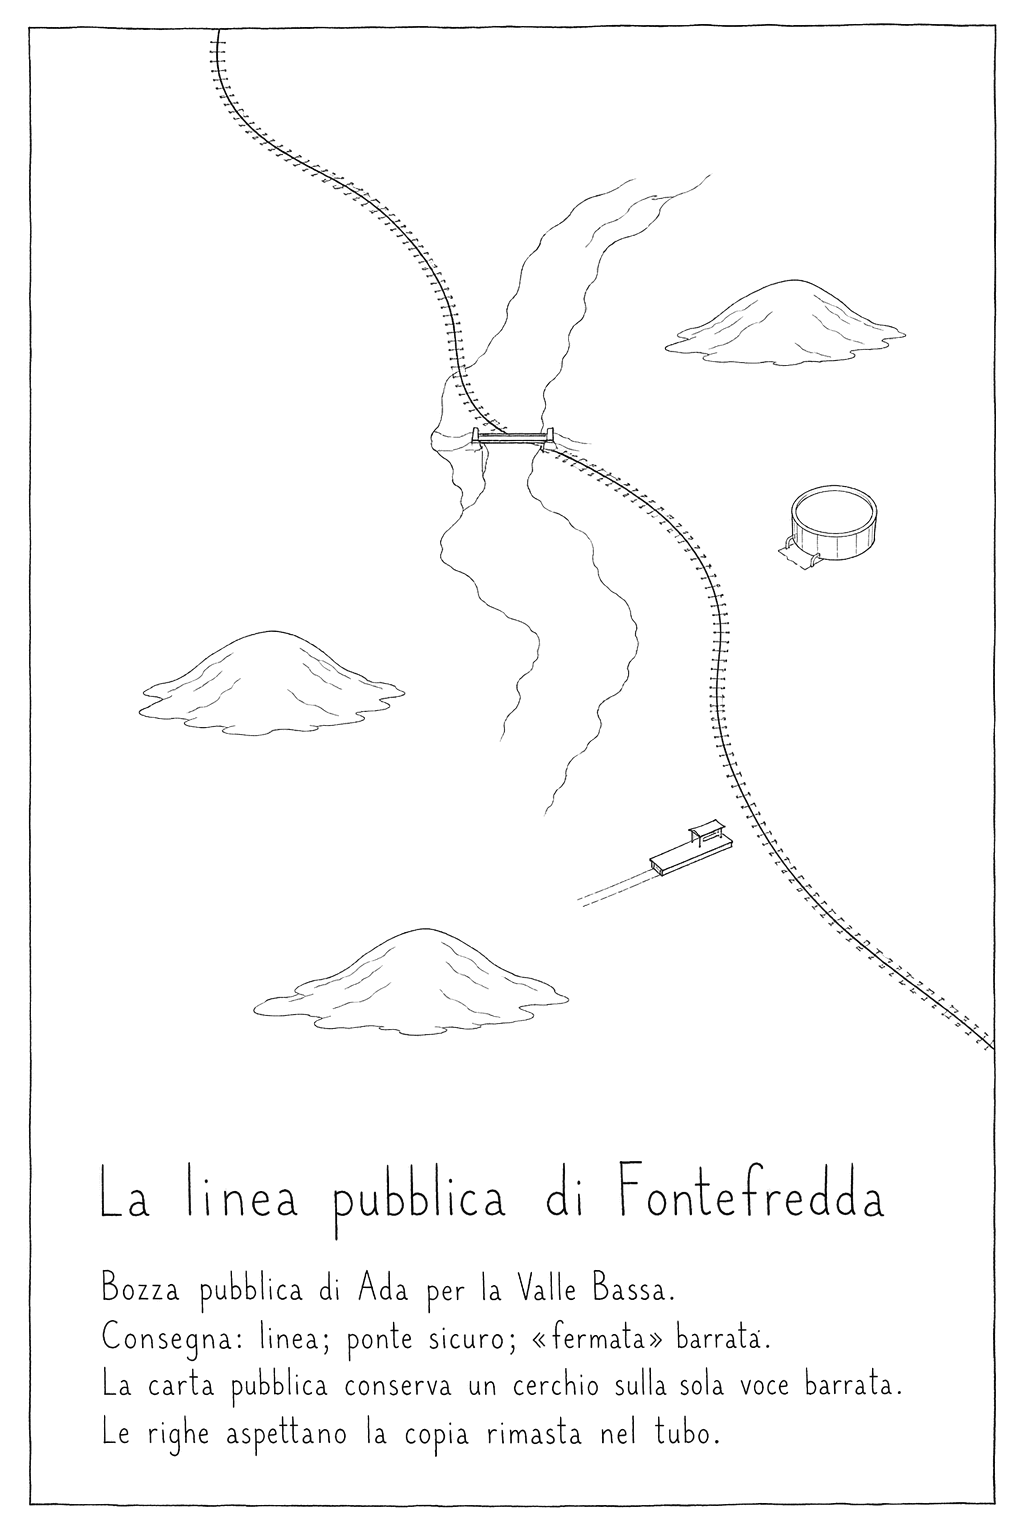

The page is a hand-drawn map, the kind folded into the back of an old book: a border, a coastline or paths, and small symbols for places.

Letter this large, as the title: "La linea pubblica di Fontefredda"
Letter this smaller, under the title: "Bozza pubblica di Ada per la Valle Bassa. Consegna: linea; ponte sicuro; «fermata» barrata. La carta pubblica conserva un cerchio sulla sola voce barrata. Le righe aspettano la copia rimasta nel tubo."

What the drawing on the page shows: A top-down fictional railway valley with one curving rail route, a narrow bridge shape, a round cistern, a small platform and three low hills. Cover the map with exact, crisp parallel lines at 1.016 mm pitch. Keep the lines uniform and uninterrupted. Include one short erased-looking branch near the platform, shown only by two faint parallel strokes. No lettering, numbers, symbols, legend or compass.
Drawn with a fine dip pen, seen from above, looking down, in the light of a bright overcast day. The line is spa

In [19]:
if isinstance(M, HandOver):
    began = time.time()
    PNG, ASKED = await PageMaker().draw(CTX, M.page)
    (ROOT / "tmp").mkdir(exist_ok=True)
    (ROOT / "tmp" / f"{M.id}.png").write_bytes(PNG)
    print(f"{time.time() - began:.1f} s · {len(PNG)} bytes")
    display(Image(PNG, width=520))
    print(ASKED)
else:
    print(f"{M.act} — nothing to draw here")

**c.** What the person did with it, if this moment collects one.

In [20]:
from string import Template

from research.calls import what_they_did

if isinstance(M, Collect):
    print(Template(P["stand-in"]).substitute(
        displays="\n".join(DISPLAYS), sheet=SHEET, mood=MOOD, minutes=MINUTES
    ))
    DID = await what_they_did(
        CTX, displays=DISPLAYS, sheet=SHEET, mood=MOOD, minutes_in=MINUTES
    )
    CAME = "marks" if str(DID.get("came")) == "marks" else "blank"
    print(f"\n{CAME} · {DID.get('onIt')} · stop: {DID.get('stop')}\n{DID.get('why')}")
else:
    CAME = None
    print(f"{M.act} — nobody is being asked for anything here")

hand_over — nobody is being asked for anything here


**d.** Take the branch, and go back to **a**.

In [21]:
AT = next_id(M, CAME)
if AT is None:
    print("over")
elif AT == ASK:
    print("the outcome says ask: the rest is bought from the continuer, in the cell below")
else:
    print(f"next: {AT}  ({BY_ID[AT].act})")

next: private-map  (hand_over)


**e.** And if the branch said `ask`, buy the rest. This is `panel/continuing.py`, the second prompt, with its own gate and its own checks and no repair.

In [22]:
from panel.continuing import continue_experience

if AT == ASK:
    began = time.time()
    CARRYING_ON, SPENT = await continue_experience(
        experience=DOCUMENT,
        after=M.id,
        came=CAME,
        reading={"came": CAME, "reading": str(DID.get("onIt", ""))},
        now=time.time(),
        pitch=ARGS["pitch"],
    )
    print(f"{time.time() - began:.1f} s · {len(CARRYING_ON.moments)} more moments\n")
    for one in CARRYING_ON.moments:
        print(f"{one.id:26} {one.act:10} {one.heading}")
    # Carry on walking into what was just bought.
    BY_ID |= {one.id: one for one in CARRYING_ON.moments}
    ORDER += [one.id for one in CARRYING_ON.moments]
    AT = CARRYING_ON.moments[0].id
else:
    print("no continuation was asked for")

no continuation was asked for


## 11. Changing a block

The blocks are the files in `agents/` and `shared/`. Edit one in the editor, run `bench.reload_prompts()`, and go back to section 4: the fingerprint changes only when the text being sent changed.

When one is settled: `python -m tools.prompts --write`, then `python -m pytest -q`, then `python -m research.run --iterations 4 --seed 0 --label <name>` — six households, four iterations, about an hour, and the eight axes are the answer to whether it improved.

⚠️ Do not run `pytest` and a run at the same time: `tests/test_trail.py` fails with `Event loop is closed` on contention, and it looks like a real regression.

In [23]:
print("fingerprint:", bench.reload_prompts())

fingerprint: bdbfb5b564f4
